In [ ]:
!pip install codecarbon

# Import libraries

In [ ]:
from torch.cuda.amp import autocast, GradScaler
from codecarbon import EmissionsTracker

import time
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import pandas as pd
import gc
import time
import os
import seaborn as sns
import matplotlib.pyplot as plt
import ast
from einops import rearrange

from tqdm import tqdm
from torchvision import datasets
from torchvision import transforms

from torch.utils.data.sampler import SubsetRandomSampler
from torch.utils.data import DataLoader, ConcatDataset

from collections import Counter

import cv2
from skimage.color import rgb2gray
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from skimage.filters import sobel, laplace
from scipy import fftpack, stats
from scipy.stats import entropy as shannon_entropy
from skimage.measure import label, regionprops

from sklearn.preprocessing import MinMaxScaler
import pickle
import pandas as pd

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
def data_loader(data_dir,
                batch_size,
                random_seed=42,
                valid_size=0.1,
                shuffle=True,
                test=False):

    normalize = transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2023, 0.1994, 0.2010],
    )

    # Images Regularization
    transform_original = transforms.Compose([
        transforms.Resize((256,256)),
        transforms.ToTensor(),
        normalize,
    ])

    # Image Augmentation
    transform_aug = transforms.Compose([
        transforms.RandomResizedCrop(256, scale=(0.8,1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2,
                               saturation=0.2, hue=0.1),
        transforms.ToTensor(),
        normalize,
        transforms.RandomErasing(p=0.1)
    ])

    if test:
        dataset = datasets.CIFAR10(
            root=data_dir, train=False,
            download=True, transform=transform_original
        )

        return DataLoader(
            dataset, batch_size=batch_size, shuffle=shuffle
        )

    # Regular Dataset
    train_dataset_orig = datasets.CIFAR10(
        root=data_dir, train=True, download=True, transform=transform_original
    )

    # Augmented Dataset
    train_dataset_aug = datasets.CIFAR10(
        root=data_dir, train=True, download=True, transform=transform_aug
    )


    # Unify the training sets and separate their data from the validation set
    num_train = len(train_dataset_orig)
    indices = list(range(num_train))
    split = int(np.floor(valid_size * num_train))

    if shuffle:
        np.random.seed(random_seed)
        np.random.shuffle(indices)

    train_idx, valid_idx = indices[split:], indices[:split]


    train_dataset = ConcatDataset([
        torch.utils.data.Subset(train_dataset_orig, train_idx),
        torch.utils.data.Subset(train_dataset_aug, train_idx)
    ])

    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True, num_workers=4
    )

    valid_dataset = torch.utils.data.Subset(train_dataset_orig, valid_idx)
    valid_loader = DataLoader(
        valid_dataset, batch_size=1, shuffle=False, num_workers=4
    )

    return train_loader, valid_loader

In [ ]:
train_loader, valid_loader = data_loader(data_dir='./data',
                                             batch_size=64)

test_loader = data_loader(data_dir='./data',
                                  batch_size=1,
                                  test=True)

In [ ]:
class ResidualBlock(nn.Module):

  def __init__(self, in_channels, out_channels, stride = 1, downsample = None):
    super(ResidualBlock, self).__init__()
    self.conv1 = nn.Sequential(
      nn.Conv2d(in_channels, out_channels, kernel_size = 3, stride = stride, padding = 1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU())
    self.conv2 = nn.Sequential(
                nn.Conv2d(out_channels, out_channels, kernel_size = 3, stride = 1, padding = 1),
                nn.BatchNorm2d(out_channels))
    self.downsample = downsample
    self.relu = nn.ReLU()
    self.out_channels = out_channels

  def forward(self, x):
      residual = x
      out = self.conv1(x)
      out = self.conv2(out)
      if self.downsample:
        residual = self.downsample(x)
      out += residual
      out = self.relu(out)
      return out

In [ ]:
class ResidualBlock50(nn.Module):
    expansion = 4

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(ResidualBlock50, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(out_channels, out_channels * self.expansion, kernel_size=1, stride=1, bias=False),
            nn.BatchNorm2d(out_channels * self.expansion)
        )
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample

    def forward(self, x):
        residual = x
        out = self.conv1(x)
        out = self.conv2(out)
        out = self.conv3(out)

        if self.downsample is not None:
            residual = self.downsample(x)

        out += residual
        out = self.relu(out)
        return out

In [ ]:
class ExitBlock(nn.Module):
    def __init__(self, in_channels, num_classes, num_convs=1):
        super(ExitBlock, self).__init__()
        layers = []
        channels = in_channels

        for _ in range(num_convs):
            layers.append(nn.Conv2d(channels, channels, kernel_size=3, stride=1, padding=1))
            layers.append(nn.BatchNorm2d(channels))
            layers.append(nn.ReLU(inplace=True))

        self.features = nn.Sequential(*layers)
        self.classifier = nn.Linear(in_channels, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = F.adaptive_avg_pool2d(x, (1, 1)).view(x.size(0), -1)
        return self.classifier(x)

In [ ]:
class ExitBlock50(nn.Module):
    def __init__(self, in_channels, num_classes, num_convs=1, reduction=0.25):
        super(ExitBlock50, self).__init__()

        reduced_channels = max(16, int(in_channels * reduction))
        layers = []

        if num_convs > 0:
            layers.append(nn.Conv2d(in_channels, reduced_channels, kernel_size=1, stride=1))
            layers.append(nn.BatchNorm2d(reduced_channels))
            layers.append(nn.ReLU(inplace=True))

            for _ in range(num_convs):
                layers.append(nn.Conv2d(reduced_channels, reduced_channels, kernel_size=3, stride=1, padding=1))
                layers.append(nn.BatchNorm2d(reduced_channels))
                layers.append(nn.ReLU(inplace=True))

            self.features = nn.Sequential(*layers)
            classifier_in = reduced_channels
        else:
            self.features = nn.Identity()
            classifier_in = in_channels

        self.classifier = nn.Linear(classifier_in, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = F.adaptive_avg_pool2d(x, (1, 1)).view(x.size(0), -1)
        return self.classifier(x)

In [ ]:
class ResNetEE18(nn.Module):
    def __init__(self, block, layers, num_classes=10, confidence_threshold=0.9):
        super(ResNetEE18, self).__init__()
        self.inplanes = 64
        self.confidence_threshold = confidence_threshold

        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer0 = self._make_layer(block, 64, layers[0], stride=1)
        self.layer1 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer2 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer3 = self._make_layer(block, 512, layers[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

        self.exit0 = ExitBlock(64, num_classes, num_convs=3)
        self.exit1 = ExitBlock(128, num_classes, num_convs=2)
        self.exit2 = ExitBlock(256, num_classes, num_convs=1)


        self.early_exits = [self.exit0, self.exit1, self.exit2]
        self.layers = [self.layer0, self.layer1, self.layer2, self.layer3]

    def _make_layer(self, block, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.inplanes != planes:
            downsample = nn.Sequential(
                nn.Conv2d(self.inplanes, planes, kernel_size=1, stride=stride),
                nn.BatchNorm2d(planes),
            )
        layers = [block(self.inplanes, planes, stride, downsample)]
        self.inplanes = planes
        for _ in range(1, blocks):
            layers.append(block(self.inplanes, planes))
        return nn.Sequential(*layers)

    def forward(self, x, exit_layer=None):
        if self.training:
            x = self.conv1(x)
            x = self.maxpool(x)

            x0 = self.layer0(x)
            out0 = self.exit0(x0)

            x1 = self.layer1(x0)
            out1 = self.exit1(x1)

            x2 = self.layer2(x1)
            out2 = self.exit2(x2)

            x3 = self.layer3(x2)

            xf = self.avgpool(x3)
            xf = torch.flatten(xf, 1)
            out_final = self.fc(xf)

            return [out0, out1, out2, out_final]

        else:

          x = self.conv1(x)
          x = self.maxpool(x)
          x = self.layer0(x)
          out0 = self.exit0(x)
          if self._confident_enough(out0):
            return out0, 0

          x = self.layer1(x)
          out1 = self.exit1(x)
          if self._confident_enough(out1):
            return out1, 1

          x = self.layer2(x)
          out2 = self.exit2(x)
          if self._confident_enough(out2):
            return out2, 2

          x = self.layer3(x)

          xf = self.avgpool(x)
          xf = torch.flatten(xf, 1)
          out_final = self.fc(xf)
          return out_final, 3

    def _confident_enough(self, logits):
        probs = F.softmax(logits, dim=1)
        conf, _ = probs.max(dim=1)
        return conf.item() >= self.confidence_threshold

In [ ]:
class ResNetEE50(nn.Module):
    def __init__(self, block, layers, num_classes=10, confidence_threshold=0.9):
        super(ResNetEE50, self).__init__()
        self.inplanes = 64
        self.confidence_threshold = confidence_threshold

        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=2, padding=3),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer0 = self._make_layer(block, 64, layers[0], stride=1)
        self.layer1 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer2 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer3 = self._make_layer(block, 512, layers[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

        self.exit0 = ExitBlock50(64 * block.expansion, num_classes, num_convs=3)
        self.exit1 = ExitBlock50(128 * block.expansion, num_classes, num_convs=2)
        self.exit2 = ExitBlock50(256 * block.expansion, num_classes, num_convs=1)

        self.early_exits = [self.exit0, self.exit1, self.exit2]
        self.layers = [self.layer0, self.layer1, self.layer2, self.layer3]

    def _make_layer(self, block, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.inplanes, planes * block.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes * block.expansion),
            )
        layers = [block(self.inplanes, planes, stride, downsample)]
        self.inplanes = planes * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.inplanes, planes))
        return nn.Sequential(*layers)

    def forward(self, x, exit_layer=None):
        if self.training:
            x = self.conv1(x)
            x = self.maxpool(x)

            x0 = self.layer0(x)
            out0 = self.exit0(x0)

            x1 = self.layer1(x0)
            out1 = self.exit1(x1)

            x2 = self.layer2(x1)
            out2 = self.exit2(x2)

            x3 = self.layer3(x2)

            xf = self.avgpool(x3)
            xf = torch.flatten(xf, 1)
            out_final = self.fc(xf)

            return [out0, out1, out2, out_final]

        else:

          x = self.conv1(x)
          x = self.maxpool(x)
          x = self.layer0(x)
          out0 = self.exit0(x)
          if self._confident_enough(out0):
            return out0, 0

          x = self.layer1(x)
          out1 = self.exit1(x)
          if self._confident_enough(out1):
            return out1, 1

          x = self.layer2(x)
          out2 = self.exit2(x)
          if self._confident_enough(out2):
            return out2, 2

          x = self.layer3(x)

          xf = self.avgpool(x)
          xf = torch.flatten(xf, 1)
          out_final = self.fc(xf)
          return out_final, 3

    def _confident_enough(self, logits):
        probs = F.softmax(logits, dim=1)
        conf, _ = probs.max(dim=1)
        return conf.item() >= self.confidence_threshold

In [ ]:
class ResNet(nn.Module):
        def __init__(self, block, layers, num_classes = 10):
            super(ResNet, self).__init__()
            self.inplanes = 64
            self.conv1 = nn.Sequential(
                            nn.Conv2d(3, 64, kernel_size = 7, stride = 2, padding = 3),
                            nn.BatchNorm2d(64),
                            nn.ReLU())
            self.maxpool = nn.MaxPool2d(kernel_size = 3, stride = 2, padding = 1)
            self.layer0 = self._make_layer(block, 64, layers[0], stride = 1)
            self.layer1 = self._make_layer(block, 128, layers[1], stride = 2)
            self.layer2 = self._make_layer(block, 256, layers[2], stride = 2)
            self.layer3 = self._make_layer(block, 512, layers[3], stride = 2)
            self.avgpool = nn.AdaptiveAvgPool2d((1,1))
            self.fc = nn.Linear(512, num_classes)

        def _make_layer(self, block, planes, blocks, stride=1):
            downsample = None
            if stride != 1 or self.inplanes != planes:

                downsample = nn.Sequential(
                    nn.Conv2d(self.inplanes, planes, kernel_size=1, stride=stride),
                    nn.BatchNorm2d(planes),
                )
            layers = []
            layers.append(block(self.inplanes, planes, stride, downsample))
            self.inplanes = planes
            for i in range(1, blocks):
                layers.append(block(self.inplanes, planes))

            return nn.Sequential(*layers)

        def forward(self, x):
            x = self.conv1(x)
            x = self.maxpool(x)
            x = self.layer0(x)
            x = self.layer1(x)
            x = self.layer2(x)
            x = self.layer3(x)

            x = self.avgpool(x)
            x = x.view(x.size(0), -1)
            x = self.fc(x)

            return x

In [ ]:
class ResNet50(nn.Module):
    def __init__(self, block, layers, num_classes=1000):
        super(ResNet50, self).__init__()
        self.inplanes = 64
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer0 = self._make_layer(block, 64, layers[0])
        self.layer1 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer2 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer3 = self._make_layer(block, 512, layers[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))  # better than fixed 7x7
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.inplanes, planes * block.expansion,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes * block.expansion),
            )

        layers = []
        layers.append(block(self.inplanes, planes, stride, downsample))
        self.inplanes = planes * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.inplanes, planes))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.maxpool(x)

        x = self.layer0(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

In [ ]:
class Gmodel(nn.Module):

  def __init__(self, hidden_dim):
        super(Gmodel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )

  def forward(self, x):
        return self.net(x).squeeze(-1)

In [ ]:
gating = Gmodel(hidden_dim=10).to(device)

In [ ]:
def train_offline1(gating_model, epochs, dataloader, batch):

  model = ResNetEE50(ResidualBlock50, [3, 4, 6, 3]).to(device)

  global_eval = [torch.tensor(0.0, device=device) for _ in range(4)]
  global_count = [torch.tensor(0.0, device=device) for _ in range(4)]

  global_coverage_eval = [torch.tensor(0.0, device=device) for _ in range(4)]
  global_coverage_count = [torch.tensor(0.0, device=device) for _ in range(4)]

  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(list(model.parameters()) + list(gating_model.parameters()), lr=1e-3)
  scaler = torch.cuda.amp.GradScaler()

  start = time.time()

  for epoch in range(epochs):
    loop = tqdm(dataloader, total=len(dataloader), desc=f"Epoch {epoch+1}/{epochs}")

    for images, labels in loop:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda"):
            outputs = model(images)

            losses = [criterion(o, labels) for o in outputs]
            pen = [gating_model(o).mean() for o in outputs]
            first_term = losses

            second_term = []

            c_term = [0, 0, 0, 0]
            phi_term = []

            for idx, o in enumerate(outputs):

              check = gating_model(o) >= 0.5
              global_eval[idx] += check.sum()
              global_count[idx] += check.numel()


              phi_term.append(global_eval[idx] / global_count[idx])

              if epoch > 1:
                pred = torch.argmax(o, dim=1)
                hit = (pred == labels).sum()

                global_coverage_eval[idx] += hit
                global_coverage_count[idx] += labels.numel()

                c_term[idx] = global_coverage_eval[idx] / global_coverage_count[idx]

            second_term = [l*d + (max(0, c-g)**2) for l, d, c, g in zip(losses, pen, c_term, phi_term)]

            denominator = [1, 2, 3, 4]

            total_loss = sum([(a+b)*c for a,b,c in zip(first_term, second_term, denominator)])
            denominator_sum = sum(denominator)
            total_loss = total_loss / denominator_sum


        scaler.scale(total_loss).backward()
        scaler.step(optimizer)
        scaler.update()
        loop.set_postfix(loss=total_loss.item())

  end = time.time()
  print(f"Elapsed time: {end - start:.4f} seconds")

  return model

In [ ]:
gating = Gmodel(hidden_dim=10).to(device)

In [ ]:
model = train_offline1(gating, 40, train_loader, 64)

In [ ]:
torch.save(model.state_dict(), "model_50_weights.pth")
torch.save(gating.state_dict(), "gating_50_weights.pth")

# Online Phase

In [ ]:
class UCB1:
    def __init__(self, arms):

        self.arms = arms
        self.n_arms = len(arms)
        self.arm_to_index = {arm: idx for idx, arm in enumerate(arms)}
        self.index_to_arm = {idx: arm for idx, arm in enumerate(arms)}

        self.counts = np.zeros(self.n_arms)
        self.values = np.zeros(self.n_arms)
        self.total_steps = 0

    def select_arm(self):
        self.total_steps += 1
        ucb_values = np.zeros(self.n_arms)

        for i in range(self.n_arms):
            if self.counts[i] == 0:
                return self.index_to_arm[i]
            average_reward = self.values[i]
            confidence = np.sqrt((2 * np.log(self.total_steps)) / self.counts[i])
            ucb_values[i] = average_reward + confidence

        selected_index = np.argmax(ucb_values)
        return self.index_to_arm[selected_index]

    def update(self, arm, reward):
        index = self.arm_to_index[arm]
        self.counts[index] += 1
        n = self.counts[index]
        value = self.values[index]
        self.values[index] += (reward - value) / n

In [ ]:
from scipy.stats import norm


class BayesUCB:

    def __init__(self, arms, mu0=0.0, lambda0=1e-6, alpha0=1.0, beta0=1.0, alpha_quant=1.0):
        self.arms = arms
        self.n_arms = len(arms)

        self.mu0 = mu0
        self.lambda0 = lambda0
        self.alpha0 = alpha0
        self.beta0 = beta0

        self.alpha_quant = alpha_quant

        self.counts = np.zeros(self.n_arms)
        self.sum_rewards = np.zeros(self.n_arms)
        self.sum_sq_rewards = np.zeros(self.n_arms)

        self.total_steps = 0

        self.arm_to_index = {arm: i for i, arm in enumerate(arms)}
        self.index_to_arm = {i: arm for i, arm in enumerate(arms)}


    def _posterior_params(self, i):
        n = self.counts[i]
        S = self.sum_rewards[i]
        Sq = self.sum_sq_rewards[i]

        lambda_n = self.lambda0 + n
        mu_n = (self.lambda0 * self.mu0 + S) / lambda_n

        alpha_n = self.alpha0 + 0.5 * n
        beta_n = self.beta0 + 0.5 * (Sq + self.lambda0 * self.mu0**2 - lambda_n * mu_n**2)

        return mu_n, lambda_n, alpha_n, beta_n


    def select_arm(self):
        self.total_steps += 1

        # Bayes-UCB quantile rule from the paper
        q_t = self._quantile()
        z = norm.ppf(q_t)

        ucb_values = np.zeros(self.n_arms)

        for i in range(self.n_arms):
            if self.counts[i] == 0:
                return self.index_to_arm[i]

            mu_n, lambda_n, alpha_n, beta_n = self._posterior_params(i)

            # sigma_post^2 = beta_n / ((alpha_n - 1) * lambda_n)
            sigma_post = np.sqrt(beta_n / ((alpha_n - 1) * lambda_n))

            ucb_values[i] = mu_n + z * sigma_post

        selected_index = np.argmax(ucb_values)
        return self.index_to_arm[selected_index]


    def update(self, arm, reward):
        i = self.arm_to_index[arm]
        self.counts[i] += 1
        self.sum_rewards[i] += reward
        self.sum_sq_rewards[i] += reward * reward

    def _quantile(self):
      t = self.total_steps
      if t < 3:
        return 0.95
      return 1 - 1.0 / (t * (np.log(t) ** self.alpha_quant))

In [ ]:
class UCB_Tuned:
    def __init__(self, arms):
        self.arms = arms
        self.n_arms = len(arms)
        self.arm_to_index = {arm: idx for idx, arm in enumerate(arms)}
        self.index_to_arm = {idx: arm for idx, arm in enumerate(arms)}

        self.counts = np.zeros(self.n_arms)
        self.values = np.zeros(self.n_arms)
        self.sum_sq_rewards = np.zeros(self.n_arms)
        self.total_steps = 0

        self.global_min_reward = np.inf
        self.global_max_reward = -np.inf

    def _scale_reward(self, reward):
        self.global_min_reward = min(self.global_min_reward, reward)
        self.global_max_reward = max(self.global_max_reward, reward)

        if self.global_max_reward == self.global_min_reward:
            return 0.5
        return (reward - self.global_min_reward) / (self.global_max_reward - self.global_min_reward)

    def select_arm(self):
        self.total_steps += 1
        ucb_values = np.zeros(self.n_arms)

        if np.any(self.counts == 0):
            return self.index_to_arm[np.argmin(self.counts)]

        log_t = np.log(self.total_steps)

        for i in range(self.n_arms):
            n_i = self.counts[i]
            mu_i = self.values[i]

            V_i = (self.sum_sq_rewards[i] / n_i) - (mu_i ** 2)

            inner_term = V_i + np.sqrt((2 * log_t) / n_i)

            V_tilde = np.minimum(inner_term, 0.25)

            ucb_values[i] = mu_i + np.sqrt((log_t / n_i) * V_tilde)

        selected_index = np.argmax(ucb_values)
        return self.index_to_arm[selected_index]

    def update(self, arm, reward):

        index = self.arm_to_index[arm]
        self.counts[index] += 1
        n = self.counts[index]

        old_mean = self.values[index]
        self.values[index] += (reward - old_mean) / n

        self.sum_sq_rewards[index] += reward ** 2

In [ ]:
class UCB_V:
    def __init__(self, arms, B=1.0):
        self.arms = arms
        self.n_arms = len(arms)
        self.arm_to_index = {arm: idx for idx, arm in enumerate(arms)}
        self.index_to_arm = {idx: arm for idx, arm in enumerate(arms)}

        self.counts = np.zeros(self.n_arms)
        self.values = np.zeros(self.n_arms)
        self.sum_sq_diff = np.zeros(self.n_arms)
        self.total_steps = 0
        self.B = B

        self.global_min_reward = np.inf
        self.global_max_reward = -np.inf

    def _scale_reward(self, reward):
        self.global_min_reward = min(self.global_min_reward, reward)
        self.global_max_reward = max(self.global_max_reward, reward)

        if self.global_max_reward == self.global_min_reward:
            return 0.5
        return (reward - self.global_min_reward) / (self.global_max_reward - self.global_min_reward)

    def select_arm(self):
        self.total_steps += 1
        ucb_values = np.zeros(self.n_arms)

        if np.any(self.counts == 0):
            return self.index_to_arm[np.argmin(self.counts)]

        log_t = np.log(self.total_steps)

        for i in range(self.n_arms):
            n_i = self.counts[i]
            mu_i = self.values[i]

            if n_i > 1:
                variance_i = self.sum_sq_diff[i] / (n_i)
            else:
                variance_i = 1e-9

            term1 = np.sqrt((2 * variance_i * log_t) / n_i)

            term2 = (3 * self.B * log_t) / n_i


            ucb_values[i] = mu_i + term1 + term2

        selected_index = np.argmax(ucb_values)
        return self.index_to_arm[selected_index]

    def update(self, arm, reward):

        index = self.arm_to_index[arm]
        self.counts[index] += 1
        n = self.counts[index]

        old_mean = self.values[index]

        self.values[index] += (reward - old_mean) / n

        new_mean = self.values[index]
        self.sum_sq_diff[index] += (reward - old_mean) * (reward - new_mean)

In [ ]:
class UCB_BwK:

    def __init__(self, thresholds):
        self.arms = thresholds
        self.n_arms = len(thresholds)
        self.arm_to_index = {arm: idx for idx, arm in enumerate(thresholds)}
        self.index_to_arm = {idx: arm for idx, arm in enumerate(thresholds)}

        self.counts = np.zeros(self.n_arms)
        self.mu_rewards = np.zeros(self.n_arms)
        self.mu_costs = np.zeros(self.n_arms)
        self.total_steps = 0

    def select_arm(self):
        self.total_steps += 1
        ucb_ratio_values = np.zeros(self.n_arms)

        if np.any(self.counts == 0):
            return self.index_to_arm[np.argmin(self.counts)]

        log_t = np.log(self.total_steps)

        for i in range(self.n_arms):
            n_i = self.counts[i]

            confidence_ratio = np.sqrt((2 * log_t) / n_i)

            ucb_rew = self.mu_rewards[i] + confidence_ratio

            tau_t = np.sqrt(np.log(self.total_steps) / self.total_steps)
            ucb_cost = max(self.mu_costs[i] - confidence_ratio, tau_t)

            ucb_ratio_values[i] = ucb_rew / ucb_cost

        selected_index = np.argmax(ucb_ratio_values)
        return self.index_to_arm[selected_index]

    def update(self, arm, reward, actual_cost):
        index = self.arm_to_index[arm]
        self.counts[index] += 1
        n = self.counts[index]

        old_mu_reward = self.mu_rewards[index]
        self.mu_rewards[index] += (reward - old_mu_reward) / n

        old_mu_cost = self.mu_costs[index]
        self.mu_costs[index] += (actual_cost - old_mu_cost) / n

In [ ]:
gating1 = Gmodel(hidden_dim=10).to(device)
gating1.load_state_dict(torch.load("/content/gating_18_weights.pth"))

gating2 = Gmodel(hidden_dim=10).to(device)
gating2.load_state_dict(torch.load("/content/gating_34_weights.pth"))

gating3 = Gmodel(hidden_dim=10).to(device)
gating3.load_state_dict(torch.load("/content/gating_50_weights.pth"))

registry = {1:gating1, 2:gating2, 3:gating3}

In [ ]:
class ResNetEE18U(nn.Module):
    def __init__(self, block, layers, num_classes=10, confidence_threshold=0.9, arms=[], bwk=False, mode=None):
        super(ResNetEE18U, self).__init__()
        self.inplanes = 64
        self.confidence_threshold = confidence_threshold

        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer0 = self._make_layer(block, 64, layers[0], stride=1)
        self.layer1 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer2 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer3 = self._make_layer(block, 512, layers[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

        self.exit0 = ExitBlock(64, num_classes, num_convs=3)
        self.exit1 = ExitBlock(128, num_classes, num_convs=2)
        self.exit2 = ExitBlock(256, num_classes, num_convs=1)


        self.early_exits = [self.exit0, self.exit1, self.exit2]
        self.layers = [self.layer0, self.layer1, self.layer2, self.layer3]

        self.thresholds = arms
        self.bwk = bwk
        self.mode = mode
        self.gating=None

        if self.mode == "ucb1":
          self.ucb = UCB1(self.thresholds)
        if self.mode == "tuned":
          self.ucb = UCB_Tuned(self.thresholds)
        if self.mode == "bwk":
          self.ucb = UCB_BwK(self.thresholds)
        if self.mode == "v":
          self.ucb = UCB_V(self.thresholds)
        if self.mode == "bayes":
          self.ucb = BayesUCB(self.thresholds)

    def select_tau(self):
        self.current_tau = self.ucb.select_arm()
        return self.current_tau

    def update_ucb(self, logits, exit_idx):
        probs = F.softmax(logits, dim=1)
        conf, _ = probs.max(dim=1)
        pro = self.gating(logits)

        if self.bwk == False:
          reward = conf*(1-pro) - 0.0025 * exit_idx
          self.ucb.update(self.current_tau, reward)

        if self.bwk == True:
          reward = conf*(1-pro)
          self.ucb.update(self.current_tau, reward=reward, actual_cost=0.0025*exit_idx)

    def _make_layer(self, block, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.inplanes != planes:
            downsample = nn.Sequential(
                nn.Conv2d(self.inplanes, planes, kernel_size=1, stride=stride),
                nn.BatchNorm2d(planes),
            )
        layers = [block(self.inplanes, planes, stride, downsample)]
        self.inplanes = planes
        for _ in range(1, blocks):
            layers.append(block(self.inplanes, planes))
        return nn.Sequential(*layers)

    def forward(self, x, exit_layer=None):
        if self.training:
            x = self.conv1(x)
            x = self.maxpool(x)

            x0 = self.layer0(x)
            out0 = self.exit0(x0)

            x1 = self.layer1(x0)
            out1 = self.exit1(x1)

            x2 = self.layer2(x1)
            out2 = self.exit2(x2)

            x3 = self.layer3(x2)

            xf = self.avgpool(x3)
            xf = torch.flatten(xf, 1)
            out_final = self.fc(xf)

            return [out0, out1, out2, out_final]

        else:

          tau = self.select_tau()

          x = self.conv1(x)
          x = self.maxpool(x)
          x = self.layer0(x)
          out0 = self.exit0(x)
          prob = F.softmax(out0, dim=1)
          con, _ = prob.max(dim=1)
          if con >= tau:
            self.update_ucb(out0, 0)
            return out0, 0

          x = self.layer1(x)
          out1 = self.exit1(x)
          prob = F.softmax(out1, dim=1)
          con, _ = prob.max(dim=1)
          if con >= tau:
            self.update_ucb(out1, 1)
            return out1, 1

          x = self.layer2(x)
          out2 = self.exit2(x)
          prob = F.softmax(out2, dim=1)
          con, _ = prob.max(dim=1)
          if con >= tau:
            self.update_ucb(out2, 2)
            return out2, 2

          x = self.layer3(x)

          xf = self.avgpool(x)
          xf = torch.flatten(xf, 1)
          out_final = self.fc(xf)
          return out_final, 3

    def _confident_enough(self, logits):
        probs = F.softmax(logits, dim=1)
        conf, _ = probs.max(dim=1)
        return conf.item() >= self.confidence_threshold

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResNetEE50U(nn.Module):
    def __init__(self, block, layers, num_classes=10, confidence_threshold=0.9, arms=[], bwk=False, mode=None):
        super(ResNetEE50U, self).__init__()
        self.inplanes = 64
        self.confidence_threshold = confidence_threshold

        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=2, padding=3),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer0 = self._make_layer(block, 64, layers[0], stride=1)
        self.layer1 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer2 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer3 = self._make_layer(block, 512, layers[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

        self.exit0 = ExitBlock50(64 * block.expansion, num_classes, num_convs=3)
        self.exit1 = ExitBlock50(128 * block.expansion, num_classes, num_convs=2)
        self.exit2 = ExitBlock50(256 * block.expansion, num_classes, num_convs=1)

        self.early_exits = [self.exit0, self.exit1, self.exit2]
        self.layers = [self.layer0, self.layer1, self.layer2, self.layer3]

        self.thresholds = arms
        self.bwk = bwk
        self.mode = mode
        self.gating=None

        if self.mode == "ucb1":
          self.ucb = UCB1(self.thresholds)
        if self.mode == "tuned":
          self.ucb = UCB_Tuned(self.thresholds)
        if self.mode == "bwk":
          self.ucb = UCB_BwK(self.thresholds)
        if self.mode == "v":
          self.ucb = UCB_V(self.thresholds)
        if self.mode == "bayes":
          self.ucb = BayesUCB(self.thresholds)

    def select_tau(self):
        self.current_tau = self.ucb.select_arm()
        return self.current_tau

    def update_ucb(self, logits, exit_idx):
        probs = F.softmax(logits, dim=1)
        conf, _ = probs.max(dim=1)
        pro = self.gating(logits)

        if self.bwk == False:
          reward = conf*(1-pro) - 0.0025 * exit_idx
          self.ucb.update(self.current_tau, reward)

        if self.bwk == True:
          reward = conf*(1-pro)
          self.ucb.update(self.current_tau, reward=reward, actual_cost=0.0025*exit_idx)

    def _make_layer(self, block, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.inplanes, planes * block.expansion,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes * block.expansion),
            )
        layers = [block(self.inplanes, planes, stride, downsample)]
        self.inplanes = planes * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.inplanes, planes))
        return nn.Sequential(*layers)

    def forward(self, x, exit_layer=None):
        if self.training:
            x = self.conv1(x)
            x = self.maxpool(x)

            x0 = self.layer0(x)
            out0 = self.exit0(x0)

            x1 = self.layer1(x0)
            out1 = self.exit1(x1)

            x2 = self.layer2(x1)
            out2 = self.exit2(x2)

            x3 = self.layer3(x2)
            xf = self.avgpool(x3)
            xf = torch.flatten(xf, 1)
            out_final = self.fc(xf)

            return [out0, out1, out2, out_final]

        else:

            tau = self.select_tau()

            x = self.conv1(x)
            x = self.maxpool(x)
            x = self.layer0(x)
            out0 = self.exit0(x)
            prob = F.softmax(out0, dim=1)
            con, _ = prob.max(dim=1)
            if con >= tau:
                self.update_ucb(out0, 0)
                return out0, 0

            x = self.layer1(x)
            out1 = self.exit1(x)
            prob = F.softmax(out1, dim=1)
            con, _ = prob.max(dim=1)
            if con >= tau:
                self.update_ucb(out1, 1)
                return out1, 1

            x = self.layer2(x)
            out2 = self.exit2(x)
            prob = F.softmax(out2, dim=1)
            con, _ = prob.max(dim=1)
            if con >= tau:
                self.update_ucb(out2, 2)
                return out2, 2

            x = self.layer3(x)
            xf = self.avgpool(x)
            xf = torch.flatten(xf, 1)
            out_final = self.fc(xf)
            return out_final, 3

    def _confident_enough(self, logits):
        probs = F.softmax(logits, dim=1)
        conf, _ = probs.max(dim=1)
        return conf.item() >= self.confidence_threshold


# CIFAR10.1v6 Evaluation

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, datasets
from PIL import Image
import numpy as np

class NumpyDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx]
        label = self.labels[idx]

        # Convert from HWC uint8 to PIL Image
        from PIL import Image
        img = Image.fromarray(img)

        if self.transform:
            img = self.transform(img)

        return img, label

In [ ]:
import numpy as np
import os
import pathlib

def load_cifar10_1_colab(version_string='v6', data_dir='/content', load_tinyimage_indices=False):

    if version_string not in ['v4', 'v6', 'v7']:
        raise ValueError(f'Unknown dataset version "{version_string}".')

    filename = f'cifar10.1_{version_string}'
    label_filepath = os.path.join(data_dir, filename + '_labels.npy')
    imagedata_filepath = os.path.join(data_dir, filename + '_data.npy')

    print(f'Loading labels from file {label_filepath}')
    assert pathlib.Path(label_filepath).is_file(), f"{label_filepath} not found!"
    labels = np.load(label_filepath, allow_pickle=True)

    print(f'Loading image data from file {imagedata_filepath}')
    assert pathlib.Path(imagedata_filepath).is_file(), f"{imagedata_filepath} not found!"
    imagedata = np.load(imagedata_filepath, allow_pickle=True)

    # Basic sanity checks
    assert len(labels.shape) == 1
    assert len(imagedata.shape) == 4
    assert labels.shape[0] == imagedata.shape[0]
    assert imagedata.shape[1] == 32 and imagedata.shape[2] == 32 and imagedata.shape[3] == 3

    # Dataset size check
    if version_string in ['v6', 'v7']:
        assert labels.shape[0] == 2000
    elif version_string == 'v4':
        assert labels.shape[0] == 2021

    if not load_tinyimage_indices:
        return imagedata, labels
    else:
        import json
        ti_indices_filepath = os.path.join(data_dir, f'{filename}_ti_indices.json')
        print(f'Loading Tiny Image indices from file {ti_indices_filepath}')
        assert pathlib.Path(ti_indices_filepath).is_file(), f"{ti_indices_filepath} not found!"
        with open(ti_indices_filepath, 'r') as f:
            tinyimage_indices = json.load(f)
        assert isinstance(tinyimage_indices, list) and len(tinyimage_indices) == labels.shape[0]
        return imagedata, labels, tinyimage_indices

In [ ]:
images, labels = load_cifar10_1_colab(version_string='v6', data_dir='/content')
print(images.shape, labels.shape)

Loading labels from file /content/cifar10.1_v6_labels.npy
Loading image data from file /content/cifar10.1_v6_data.npy
(2000, 32, 32, 3) (2000,)


In [ ]:
normalize = transforms.Normalize(
    mean=[0.4914, 0.4822, 0.4465],
    std=[0.2023, 0.1994, 0.2010],
)

transform_original = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    normalize,
])

test_dataset = NumpyDataset(images, labels, transform=transform_original)

test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

for imgs, lbls in test_loader:
    print(imgs.shape, lbls.shape)
    break

torch.Size([1, 3, 256, 256]) torch.Size([1])


In [ ]:
model_arms1_50 = ResNetEE50U(ResidualBlock50, [3, 4, 6, 3], arms=[0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95], mode='ucb1').to(device)
model_arms1_50.load_state_dict(torch.load("/content/model_50_weights.pth"))
model_arms1_50.gating=registry[3]

In [ ]:
model_arms2_50 = ResNetEE50U(ResidualBlock50, [3, 4, 6, 3], arms=[0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9], mode='ucb1').to(device)
model_arms2_50.load_state_dict(torch.load("/content/model_50_weights.pth"))
model_arms2_50.gating=registry[3]

In [ ]:
model_arms3_50 = ResNetEE50U(ResidualBlock50, [3, 4, 6, 3], arms=[ 0.75, 0.8, 0.85, 0.9], mode='ucb1').to(device)
model_arms3_50.load_state_dict(torch.load("/content/model_50_weights.pth"))
model_arms3_50.gating=registry[3]

In [ ]:
model_arms4_50 = ResNetEE50U(ResidualBlock50, [3, 4, 6, 3], arms=[0.8, 0.85, 0.9, 0.95], mode='ucb1').to(device)
model_arms4_50.load_state_dict(torch.load("/content/model_50_weights.pth"))
model_arms4_50.gating=registry[3]

In [ ]:
model_arms5_50 = ResNetEE50U(ResidualBlock50, [3, 4, 6, 3], arms=[0.8, 0.85, 0.9], mode='ucb1').to(device)
model_arms5_50.load_state_dict(torch.load("/content/model_50_weights.pth"))
model_arms5_50.gating=registry[3]

In [ ]:
model_arms6_50 = ResNetEE50U(ResidualBlock50, [3, 4, 6, 3], arms=[0.75, 0.8, 0.85], mode='ucb1').to(device)
model_arms6_50.load_state_dict(torch.load("/content/drive/model_50_weights.pth"))
model_arms6_50.gating=registry[3]

In [ ]:
model_arms7_50 = ResNetEE50U(ResidualBlock50, [3, 4, 6, 3], arms=[0.85, 0.9, 0.95], mode='ucb1').to(device)
model_arms7_50.load_state_dict(torch.load("/content/model_50_weights.pth"))
model_arms7_50.gating=registry[3]

In [ ]:
model_EE_50 = ResNetEE50(ResidualBlock50, [3, 4, 6, 3]).to(device)
model_EE_50.load_state_dict(torch.load("/content/model_weights_resnet503_EE.pth"))

In [ ]:
model_50 = ResNet50(ResidualBlock50, [3, 4, 6, 3]).to(device)
model_50.load_state_dict(torch.load("/content/model_weights_resnet50.pth"))

<All keys matched successfully>

## Diagrams - UCB1



In [ ]:
all = {
    'resnet50':model_50,
    'ee_50':model_EE_50,
    'ee_50_arms1_UCB1':model_arms1_50,
    'ee_50_arms2_UCB1':model_arms2_50,
    'ee_50_arms3_UCB1':model_arms3_50,
    'ee_50_arms4_UCB1':model_arms4_50,
    'ee_50_arms5_UCB1':model_arms5_50,
    'ee_50_arms6_UCB1':model_arms6_50,
    'ee_50_arms7_UCB1':model_arms7_50
}

In [ ]:
def evaluate_model(model, model_name, test_loader, early=False):
    model.eval()

    correct = 0
    total = 0
    NUM_EXITS = 4
    exit_counts = [0] * NUM_EXITS if early else None

    start_time = time.time()
    tracker = EmissionsTracker(measure_power_secs=1)
    tracker.start()

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            if early:
                preds, exit_id = model(images)
                exit_counts[exit_id] += 1
            else:
                preds = model(images)

            predicted = preds.argmax(dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    tracker.stop()
    end_time = time.time()

    accuracy = 100 * correct / total
    inference_time = end_time - start_time

    data = tracker._prepare_emissions_data()
    energy = data.energy_consumed

    result = {
        "model_name": model_name,
        "accuracy": accuracy,
        "inference_time_sec": inference_time,
        "energy_kWh": energy,
    }

    for i in range(4):
        if early:
            result[f"exit_{i}_count"] = exit_counts[i]
        else:
            result[f"exit_{i}_count"] = float('nan')

    return result

def extract_data(models, test_loader):

  all_results = []

  for name, model in models.items():
    print(name)
    if name == 'resnet18' or name == 'resnet34' or name == 'resnet50':
      res = evaluate_model(model, name, test_loader, early=False)
    else:
      res = evaluate_model(model, name, test_loader, early=True)

    all_results.append(res)

  df = pd.DataFrame(all_results)

  return df

In [ ]:
data = extract_data(all, test_loader)

In [ ]:
data.to_csv('ucb1_resnet_10.1v6_results.csv')

# UCB Tuned

## ResNet50 Models Load

In [ ]:
model_arms1_50 = ResNetEE50U(ResidualBlock50, [3, 4, 6, 3], arms=[0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95], mode='tuned').to(device)
model_arms1_50.load_state_dict(torch.load("/content/model_50_weights.pth"))
model_arms1_50.gating=registry[3]

In [ ]:
model_arms2_50 = ResNetEE50U(ResidualBlock50, [3, 4, 6, 3], arms=[0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9], mode='tuned').to(device)
model_arms2_50.load_state_dict(torch.load("/content/model_50_weights.pth"))
model_arms2_50.gating=registry[3]

In [ ]:
model_arms3_50 = ResNetEE50U(ResidualBlock50, [3, 4, 6, 3], arms=[ 0.75, 0.8, 0.85, 0.9], mode='tuned').to(device)
model_arms3_50.load_state_dict(torch.load("/content/model_50_weights.pth"))
model_arms3_50.gating=registry[3]

In [ ]:
model_arms4_50 = ResNetEE50U(ResidualBlock50, [3, 4, 6, 3], arms=[0.8, 0.85, 0.9, 0.95], mode='tuned').to(device)
model_arms4_50.load_state_dict(torch.load("/content/model_50_weights.pth"))
model_arms4_50.gating=registry[3]

In [ ]:
model_arms5_50 = ResNetEE50U(ResidualBlock50, [3, 4, 6, 3], arms=[0.8, 0.85, 0.9], mode='tuned').to(device)
model_arms5_50.load_state_dict(torch.load("/content/model_50_weights.pth"))
model_arms5_50.gating=registry[3]

In [ ]:
model_arms6_50 = ResNetEE50U(ResidualBlock50, [3, 4, 6, 3], arms=[0.75, 0.8, 0.85], mode='tuned').to(device)
model_arms6_50.load_state_dict(torch.load("/content/model_50_weights.pth"))
model_arms6_50.gating=registry[3]

In [ ]:
model_arms7_50 = ResNetEE50U(ResidualBlock50, [3, 4, 6, 3], arms=[0.85, 0.9, 0.95], mode='tuned').to(device)
model_arms7_50.load_state_dict(torch.load("/content/model_50_weights.pth"))
model_arms7_50.gating=registry[3]

In [ ]:
model_EE_50 = ResNetEE50(ResidualBlock50, [3, 4, 6, 3]).to(device)
model_EE_50.load_state_dict(torch.load("/content/model_weights_resnet503_EE.pth"))

<All keys matched successfully>

In [ ]:
model_50 = ResNet50(ResidualBlock50, [3, 4, 6, 3]).to(device)
model_50.load_state_dict(torch.load("/content/model_weights_resnet50.pth"))

<All keys matched successfully>

## Diagrams - UCB Tuned



In [ ]:
all = {
    'resnet50':model_50,
    'ee_50':model_EE_50,
    'ee_50_arms1_UCB1':model_arms1_50,
    'ee_50_arms2_UCB1':model_arms2_50,
    'ee_50_arms3_UCB1':model_arms3_50,
    'ee_50_arms4_UCB1':model_arms4_50,
    'ee_50_arms5_UCB1':model_arms5_50,
    'ee_50_arms6_UCB1':model_arms6_50,
    'ee_50_arms7_UCB1':model_arms7_50
}

In [ ]:
data = extract_data(all, test_loader)

In [ ]:
data.to_csv('ucb_tuned_resnet_10.1v6_results.csv')

# UCB BwK

## ResNet50 Models Load

In [ ]:
model_arms1_50 = ResNetEE50U(ResidualBlock50, [3, 4, 6, 3], arms=[0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95], bwk=True, mode='bwk').to(device)
model_arms1_50.load_state_dict(torch.load("/content/model_50_weights.pth"))
model_arms1_50.gating=registry[3]

In [ ]:
model_arms2_50 = ResNetEE50U(ResidualBlock50, [3, 4, 6, 3], arms=[0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9], bwk=True, mode='bwk').to(device)
model_arms2_50.load_state_dict(torch.load("/content/model_50_weights.pth"))
model_arms2_50.gating=registry[3]

In [ ]:
model_arms3_50 = ResNetEE50U(ResidualBlock50, [3, 4, 6, 3], arms=[ 0.75, 0.8, 0.85, 0.9], bwk=True, mode='bwk').to(device)
model_arms3_50.load_state_dict(torch.load("/content/drive/model_50_weights.pth"))
model_arms3_50.gating=registry[3]

In [ ]:
model_arms4_50 = ResNetEE50U(ResidualBlock50, [3, 4, 6, 3], arms=[0.8, 0.85, 0.9, 0.95], bwk=True, mode='bwk').to(device)
model_arms4_50.load_state_dict(torch.load("/content/drive/model_50_weights.pth"))
model_arms4_50.gating=registry[3]

In [ ]:
model_arms5_50 = ResNetEE50U(ResidualBlock50, [3, 4, 6, 3], arms=[0.8, 0.85, 0.9], bwk=True, mode='bwk').to(device)
model_arms5_50.load_state_dict(torch.load("/content/drive/model_50_weights.pth"))
model_arms5_50.gating=registry[3]

In [ ]:
model_arms6_50 = ResNetEE50U(ResidualBlock50, [3, 4, 6, 3], arms=[0.75, 0.8, 0.85], bwk=True, mode='bwk').to(device)
model_arms6_50.load_state_dict(torch.load("/content/drive/model_50_weights.pth"))
model_arms6_50.gating=registry[3]

In [ ]:
model_arms7_50 = ResNetEE50U(ResidualBlock50, [3, 4, 6, 3], arms=[0.85, 0.9, 0.95], bwk=True, mode='bwk').to(device)
model_arms7_50.load_state_dict(torch.load("/content/drive/model_50_weights.pth"))
model_arms7_50.gating=registry[3]

In [ ]:
model_EE_50 = ResNetEE50(ResidualBlock50, [3, 4, 6, 3]).to(device)
model_EE_50.load_state_dict(torch.load("/content/drive/model_weights_resnet503_EE.pth"))

<All keys matched successfully>

In [ ]:
model_50 = ResNet50(ResidualBlock50, [3, 4, 6, 3]).to(device)
model_50.load_state_dict(torch.load("/content/drive/model_weights_resnet50.pth"))

## Diagrams - UCB BwK



In [ ]:
all = {
    'resnet50':model_50,
    'ee_50':model_EE_50,
    'ee_50_arms1_UCB1':model_arms1_50,
    'ee_50_arms2_UCB1':model_arms2_50,
    'ee_50_arms3_UCB1':model_arms3_50,
    'ee_50_arms4_UCB1':model_arms4_50,
    'ee_50_arms5_UCB1':model_arms5_50,
    'ee_50_arms6_UCB1':model_arms6_50,
    'ee_50_arms7_UCB1':model_arms7_50
}

In [ ]:
data = extract_data(all, test_loader)

In [ ]:
data.to_csv('ucb_bwk_resnet_10.1v6_results.csv')

































# UCB V

## ResNet50 Models Load

In [ ]:
model_arms1_50 = ResNetEE50U(ResidualBlock50, [3, 4, 6, 3], arms=[0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95], mode='v').to(device)
model_arms1_50.load_state_dict(torch.load("/content/drive/model_50_weights.pth"))
model_arms1_50.gating=registry[3]

In [ ]:
model_arms2_50 = ResNetEE50U(ResidualBlock50, [3, 4, 6, 3], arms=[0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9], mode='v').to(device)
model_arms2_50.load_state_dict(torch.load("/content/drive/model_50_weights.pth"))
model_arms2_50.gating=registry[3]

In [ ]:
model_arms3_50 = ResNetEE50U(ResidualBlock50, [3, 4, 6, 3], arms=[ 0.75, 0.8, 0.85, 0.9], mode='v').to(device)
model_arms3_50.load_state_dict(torch.load("/content/drive/model_50_weights.pth"))
model_arms3_50.gating=registry[3]

In [ ]:
model_arms4_50 = ResNetEE50U(ResidualBlock50, [3, 4, 6, 3], arms=[0.8, 0.85, 0.9, 0.95], mode='v').to(device)
model_arms4_50.load_state_dict(torch.load("/content/drive/model_50_weights.pth"))
model_arms4_50.gating=registry[3]

In [ ]:
model_arms5_50 = ResNetEE50U(ResidualBlock50, [3, 4, 6, 3], arms=[0.8, 0.85, 0.9], mode='v').to(device)
model_arms5_50.load_state_dict(torch.load("/content/drive/model_50_weights.pth"))
model_arms5_50.gating=registry[3]

In [ ]:
model_arms6_50 = ResNetEE50U(ResidualBlock50, [3, 4, 6, 3], arms=[0.75, 0.8, 0.85], mode='v').to(device)
model_arms6_50.load_state_dict(torch.load("/content/drive/model_50_weights.pth"))
model_arms6_50.gating=registry[3]

In [ ]:
model_arms7_50 = ResNetEE50U(ResidualBlock50, [3, 4, 6, 3], arms=[0.85, 0.9, 0.95], mode='v').to(device)
model_arms7_50.load_state_dict(torch.load("/content/drive/model_50_weights.pth"))
model_arms7_50.gating=registry[3]

In [ ]:
model_EE_50 = ResNetEE50(ResidualBlock50, [3, 4, 6, 3]).to(device)
model_EE_50.load_state_dict(torch.load("/content/drive/model_weights_resnet503_EE.pth"))

<All keys matched successfully>

In [ ]:
model_50 = ResNet50(ResidualBlock50, [3, 4, 6, 3]).to(device)
model_50.load_state_dict(torch.load("/content/drive/model_weights_resnet50.pth"))

<All keys matched successfully>

## Diagrams - UCB V



In [ ]:
all = {
    'resnet50':model_50,
    'ee_50':model_EE_50,
    'ee_50_arms1_UCB1':model_arms1_50,
    'ee_50_arms2_UCB1':model_arms2_50,
    'ee_50_arms3_UCB1':model_arms3_50,
    'ee_50_arms4_UCB1':model_arms4_50,
    'ee_50_arms5_UCB1':model_arms5_50,
    'ee_50_arms6_UCB1':model_arms6_50,
    'ee_50_arms7_UCB1':model_arms7_50
}

In [ ]:
data.to_csv('ucb_v_resnet_10.1v6_results.csv')

# UCB Bayes

## ResNet50 Models Load

In [ ]:
model_arms1_50 = ResNetEE50U(ResidualBlock50, [3, 4, 6, 3], arms=[0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95], mode='bayes').to(device)
model_arms1_50.load_state_dict(torch.load("/content/drive/model_50_weights.pth"))
model_arms1_50.gating=registry[3]

In [ ]:
model_arms2_50 = ResNetEE50U(ResidualBlock50, [3, 4, 6, 3], arms=[0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9], mode='bayes').to(device)
model_arms2_50.load_state_dict(torch.load("/content/drive/model_50_weights.pth"))
model_arms2_50.gating=registry[3]

In [ ]:
model_arms3_50 = ResNetEE50U(ResidualBlock50, [3, 4, 6, 3], arms=[ 0.75, 0.8, 0.85, 0.9], mode='bayes').to(device)
model_arms3_50.load_state_dict(torch.load("/content/drive/model_50_weights.pth"))
model_arms3_50.gating=registry[3]

In [ ]:
model_arms4_50 = ResNetEE50U(ResidualBlock50, [3, 4, 6, 3], arms=[0.8, 0.85, 0.9, 0.95], mode='bayes').to(device)
model_arms4_50.load_state_dict(torch.load("/content/drive/model_50_weights.pth"))
model_arms4_50.gating=registry[3]

In [ ]:
model_arms5_50 = ResNetEE50U(ResidualBlock50, [3, 4, 6, 3], arms=[0.8, 0.85, 0.9], mode='bayes').to(device)
model_arms5_50.load_state_dict(torch.load("/content/drive/model_50_weights.pth"))
model_arms5_50.gating=registry[3]

In [ ]:
model_arms6_50 = ResNetEE50U(ResidualBlock50, [3, 4, 6, 3], arms=[0.75, 0.8, 0.85], mode='bayes').to(device)
model_arms6_50.load_state_dict(torch.load("/content/drive/model_50_weights.pth"))
model_arms6_50.gating=registry[3]

In [ ]:
model_arms7_50 = ResNetEE50U(ResidualBlock50, [3, 4, 6, 3], arms=[0.85, 0.9, 0.95], mode='bayes').to(device)
model_arms7_50.load_state_dict(torch.load("/content/drive/model_50_weights.pth"))
model_arms7_50.gating=registry[3]

In [ ]:
model_EE_50 = ResNetEE50(ResidualBlock50, [3, 4, 6, 3]).to(device)
model_EE_50.load_state_dict(torch.load("/content/drive/model_weights_resnet503_EE.pth"))

<All keys matched successfully>

In [ ]:
model_50 = ResNet50(ResidualBlock50, [3, 4, 6, 3]).to(device)
model_50.load_state_dict(torch.load("/content/drive/model_weights_resnet50.pth"))

[codecarbon INFO @ 21:29:39] Energy consumed for RAM : 0.009290 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 21:29:39] Delta energy consumed for CPU with constant : 0.000012 kWh, power : 42.5 W
[codecarbon INFO @ 21:29:39] Energy consumed for All CPU : 0.019768 kWh
[codecarbon INFO @ 21:29:39] Energy consumed for all GPUs : 0.019419 kWh. Total GPU Power : 34.542739177578454 W
[codecarbon INFO @ 21:29:39] 0.048477 kWh of electricity and 0.000000 L of water were used since the beginning.


<All keys matched successfully>

## Diagrams - UCB Bayes





In [ ]:
all = {
    'resnet50':model_50,
    'ee_50':model_EE_50,
    'ee_50_arms1_UCB1':model_arms1_50,
    'ee_50_arms2_UCB1':model_arms2_50,
    'ee_50_arms3_UCB1':model_arms3_50,
    'ee_50_arms4_UCB1':model_arms4_50,
    'ee_50_arms5_UCB1':model_arms5_50,
    'ee_50_arms6_UCB1':model_arms6_50,
    'ee_50_arms7_UCB1':model_arms7_50
}

In [ ]:
data = extract_data(all, test_loader)

In [ ]:
data.to_csv('ucb_bayes_resnet_10.1v6_results.csv')

# Data Aggregation - UCB Selection

In [ ]:
ucb1 = pd.read_csv('ucb1_resnet_10.1v6_results.csv')
bayes = pd.read_csv('ucb_bayes_resnet_10.1v6_results.csv')
tuned = pd.read_csv('ucb_tuned_resnet_10.1v6_results.csv')
bwk = pd.read_csv('ucb_bwk_resnet_10.1v6_results.csv')
v = pd.read_csv('ucb_v_resnet_10.1v6_results.csv')

In [ ]:
import pandas as pd

def replace_in_column(df: pd.DataFrame, column: str, old: str, new: str) -> pd.DataFrame:
    if column not in df.columns:
        raise ValueError(f"Column '{column}' does not exist in the DataFrame.")

    df[column] = df[column].astype(str).apply(lambda x: x.replace(old, new))
    df.drop(['Unnamed: 0'], inplace=True, axis=1)
    return df

In [ ]:
bayes = replace_in_column(bayes, 'model_name', '_UCB1', '_UCB_Bayes')

In [ ]:
tuned = replace_in_column(tuned, 'model_name', '_UCB1', '_UCB_Tuned')

In [ ]:
v = replace_in_column(v, 'model_name', '_UCB1', '_UCB_V')

In [ ]:
bwk = replace_in_column(bwk, 'model_name', '_UCB1', '_UCB_BwK')

In [ ]:
con = pd.concat([ucb1, bayes, tuned, bwk, v], ignore_index=True, axis=0)
con.drop(['Unnamed: 0'], inplace=True, axis=1)

In [ ]:
con.drop_duplicates(['model_name'], inplace=True)

In [ ]:
con.shape

(111, 9)

# Accuracy - Inference Time tradeoff

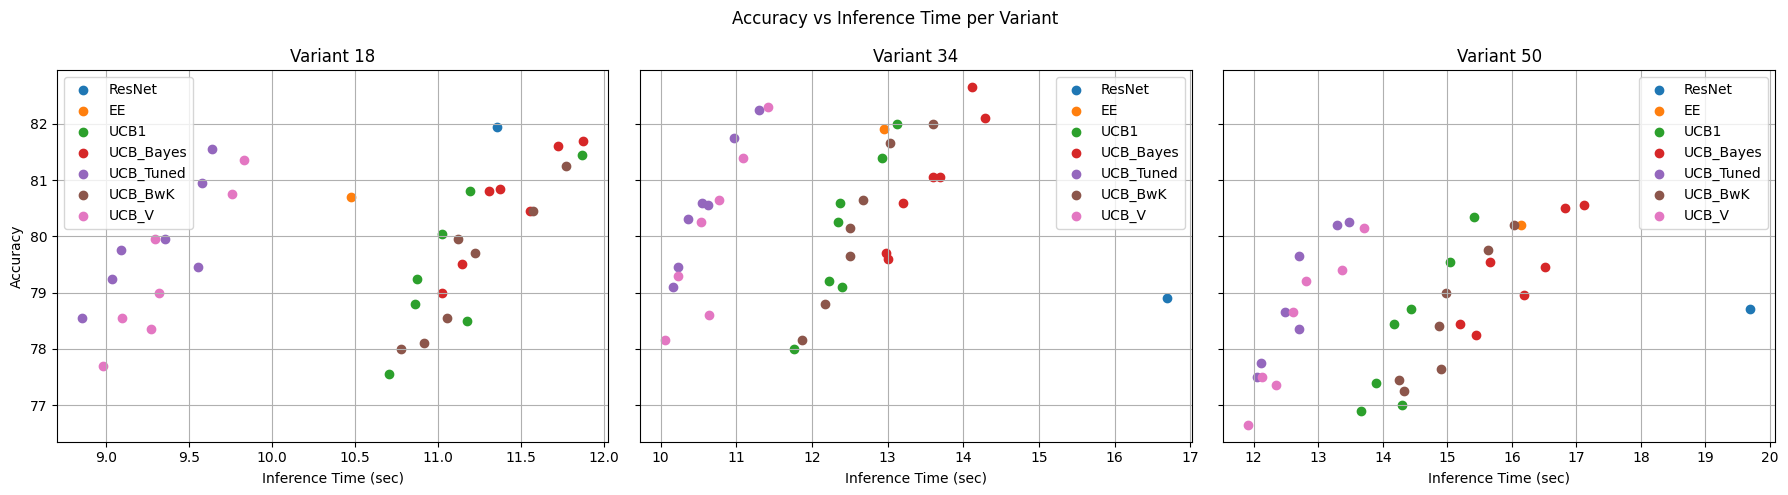

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


def get_family(model_name):
    if model_name.startswith("resnet"):
        return "ResNet"

    if "ee" in model_name and "UCB" not in model_name:
        return "EE"

    if "UCB1" in model_name:
        return "UCB1"
    if "UCB_Bayes" in model_name:
        return "UCB_Bayes"
    if "UCB_Tuned" in model_name:
        return "UCB_Tuned"
    if "UCB_BwK" in model_name:
        return "UCB_BwK"
    if "UCB_V" in model_name:
        return "UCB_V"
    if "EUCBV" in model_name:
      return "EUCBV"

    return "other"

def get_variant(model_name):
    if "18" in model_name:
        return "18"
    if "34" in model_name:
        return "34"
    if "50" in model_name:
        return "50"
    return "other"

con['model_name'] = con['model_name'].astype(str)
con["family"] = con["model_name"].apply(get_family)
con["variant"] = con["model_name"].apply(get_variant)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

variants = ["18", "34", "50"]

for ax, v in zip(axes, variants):
    sub = con[con["variant"] == v]
    families = sub["family"].unique()

    for fam in families:
        fam_data = sub[sub["family"] == fam]
        ax.scatter(
            fam_data["inference_time_sec"],
            fam_data["accuracy"],
            label=fam
        )

    ax.set_title(f"Variant {v}")
    ax.set_xlabel("Inference Time (sec)")
    ax.grid(True)
    if v == "18":
        ax.set_ylabel("Accuracy")
    ax.legend()

plt.suptitle("Accuracy vs Inference Time per Variant")
plt.tight_layout()
plt.savefig("accuracy_inf.pdf")


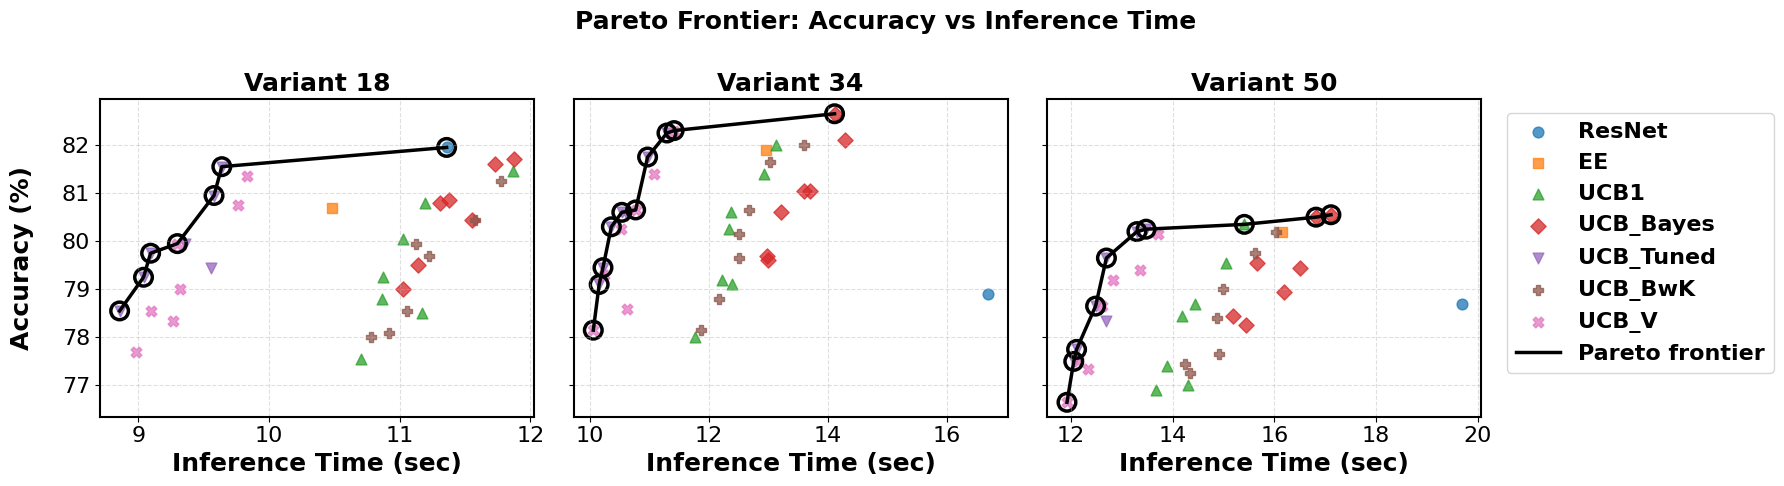

In [ ]:
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "figure.titlesize": 18,
    "lines.linewidth": 2.5
})

def pareto_front_2d(df, x_col, y_col):
    df_sorted = df.sort_values(x_col, ascending=True)  # Minimize x
    pareto = []
    best_y = -np.inf

    for _, row in df_sorted.iterrows():
        y = row[y_col]
        if y > best_y:
            pareto.append(row)
            best_y = y

    return pd.DataFrame(pareto)

x_metrics = ["inference_time_sec"]
variants = ["18", "34", "50"]

for x_col in x_metrics:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    fig.suptitle("Pareto Frontier: Accuracy vs Inference Time", fontweight="bold")

    for ax, v in zip(axes, variants):
        sub = con[con["variant"] == v]

        families = sub["family"].unique()

        marker_cycle = [
          "o",
          "s",
          "^",
          "D",
          "v",
          "P",
          "X",
        ]

        family_to_marker = {
          fam: marker_cycle[i % len(marker_cycle)]
          for i, fam in enumerate(families)
        }

        families = sub["family"].unique()
        for fam in families:
            fam_data = sub[sub["family"] == fam]
            ax.scatter(
                fam_data[x_col],
                fam_data["accuracy"],
                marker=family_to_marker[fam],
                s=60,
                alpha=0.75,
                label=fam
            )

        pareto = pareto_front_2d(sub, x_col, "accuracy")

        ax.plot(
            pareto[x_col],
            pareto["accuracy"],
            color="black",
            label="Pareto frontier"
        )

        ax.scatter(
            pareto[x_col],
            pareto["accuracy"],
            s=160,
            facecolors="none",
            edgecolors="black",
            linewidth=2.5
        )

        ax.set_title(f"Variant {v}")
        ax.set_xlabel("Inference Time (sec)")

        if v == "18":
            ax.set_ylabel("Accuracy (%)", labelpad=20)

        ax.grid(True, linestyle="--", alpha=0.4)

        for spine in ax.spines.values():
            spine.set_linewidth(1.5)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="center right",
        frameon=True, prop={"weight": "bold"}
    )

    plt.tight_layout(rect=[0, 0, 0.85, 1])

    plt.savefig("accuracy_inf.pdf", dpi=300, bbox_inches="tight")


# Accuracy - Energy tradeoff

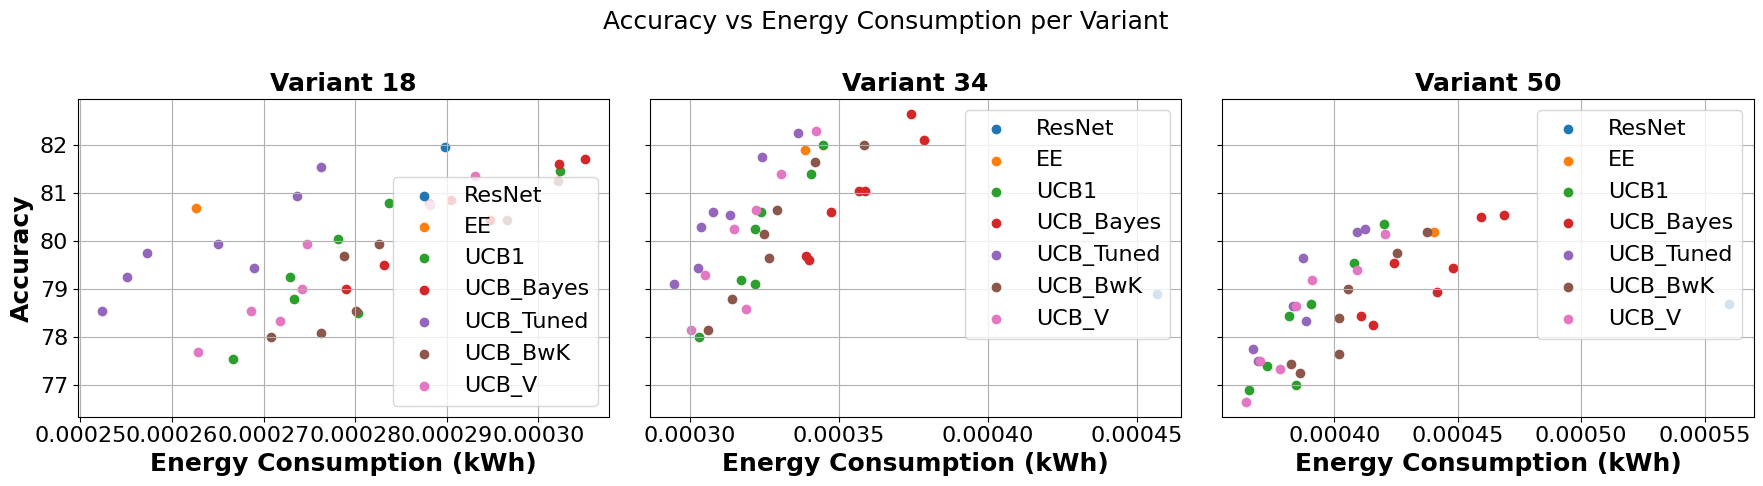

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


def get_family(model_name):
    if model_name.startswith("resnet"):
        return "ResNet"

    if "ee" in model_name and "UCB" not in model_name:
        return "EE"

    if "UCB1" in model_name:
        return "UCB1"
    if "UCB_Bayes" in model_name:
        return "UCB_Bayes"
    if "UCB_Tuned" in model_name:
        return "UCB_Tuned"
    if "UCB_BwK" in model_name:
        return "UCB_BwK"
    if "UCB_V" in model_name:
        return "UCB_V"
    if "EUCBV" in model_name:
      return "EUCBV"

    return "other"

def get_variant(model_name):
    if "18" in model_name:
        return "18"
    if "34" in model_name:
        return "34"
    if "50" in model_name:
        return "50"
    return "other"

con['model_name'] = con['model_name'].astype(str)
con["family"] = con["model_name"].apply(get_family)
con["variant"] = con["model_name"].apply(get_variant)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

variants = ["18", "34", "50"]

for ax, v in zip(axes, variants):
    sub = con[con["variant"] == v]
    families = sub["family"].unique()

    for fam in families:
        fam_data = sub[sub["family"] == fam]
        ax.scatter(
            fam_data["energy_kWh"],
            fam_data["accuracy"],
            label=fam
        )

    ax.set_title(f"Variant {v}")
    ax.set_xlabel("Energy Consumption (kWh)")
    ax.grid(True)
    if v == "18":
        ax.set_ylabel("Accuracy")
    ax.legend()

plt.suptitle("Accuracy vs Energy Consumption per Variant")
plt.tight_layout()
plt.savefig("acccuracy_flops.pdf")

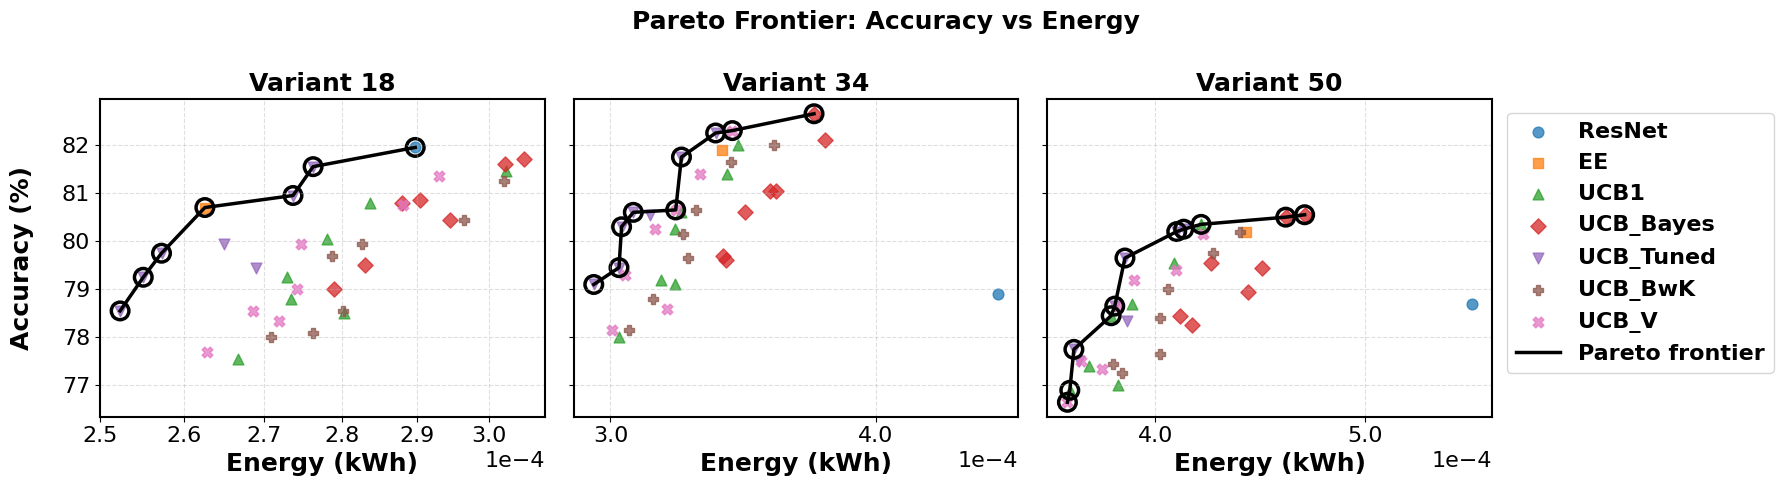

In [ ]:
from matplotlib.ticker import LogLocator, ScalarFormatter
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "figure.titlesize": 18,
    "lines.linewidth": 2.5
})

def pareto_front_2d(df, x_col, y_col):
    df_sorted = df.sort_values(x_col, ascending=True)  # Minimize x
    pareto = []
    best_y = -np.inf

    for _, row in df_sorted.iterrows():
        y = row[y_col]
        if y > best_y:
            pareto.append(row)
            best_y = y

    return pd.DataFrame(pareto)

x_metrics = ["energy_kWh"]
variants = ["18", "34", "50"]

for x_col in x_metrics:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    fig.suptitle("Pareto Frontier: Accuracy vs Energy", fontweight="bold")

    for ax, v in zip(axes, variants):
        sub = con[con["variant"] == v]

        families = sub["family"].unique()

        marker_cycle = [
          "o",
          "s",
          "^",
          "D",
          "v",
          "P",
          "X",
        ]

        family_to_marker = {
          fam: marker_cycle[i % len(marker_cycle)]
          for i, fam in enumerate(families)
        }

        families = sub["family"].unique()
        for fam in families:
            fam_data = sub[sub["family"] == fam]
            ax.scatter(
                fam_data[x_col],
                fam_data["accuracy"],
                marker=family_to_marker[fam],
                s=60,
                alpha=0.75,
                label=fam
            )

        pareto = pareto_front_2d(sub, x_col, "accuracy")
        ax.plot(
            pareto[x_col],
            pareto["accuracy"],
            color="black",
            label="Pareto frontier"
        )

        ax.scatter(
            pareto[x_col],
            pareto["accuracy"],
            s=160,
            facecolors="none",
            edgecolors="black",
            linewidth=2.5
        )

        ax.set_title(f"Variant {v}")
        ax.set_xlabel("Energy (kWh)")
        if v == "18":
            ax.set_ylabel("Accuracy (%)", labelpad=20)

        ax.grid(True, linestyle="--", alpha=0.4)

        for spine in ax.spines.values():
            spine.set_linewidth(1.5)

        ax.set_xscale('log')
        ax.xaxis.set_major_locator(LogLocator(base=10.0, subs=None))
        ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1, 10)*0.1, numticks=10))
        ax.xaxis.set_major_formatter(ScalarFormatter())
        ax.ticklabel_format(axis='x', style='sci', scilimits=(0,0))

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="center right",
        frameon=True, prop={"weight": "bold"}
    )

    # Reserve space for legend
    plt.tight_layout(rect=[0, 0, 0.85, 1])

    # Save figure
    plt.savefig("accuracy_energy.pdf", dpi=300, bbox_inches="tight")